# ATC Speech Enhancement: ASR‑Driven Training (Approach 2)

This notebook implements an **ASR‑driven speech enhancement pipeline** for Air Traffic Control (ATC) audio.  
Instead of relying on clean audio references (which do not exist for real ATC), we train an enhancer to maximise the transcription accuracy of a downstream automatic speech recognition (ASR) model.

Key features:
- On‑the‑fly data augmentation: mixing clean ATC speech with various noise sources at SNRs from **‑20 dB to +5 dB**, plus realistic **VHF channel simulation** (bandpass filter, non‑linear distortion, fading).
- A **Demucs waveform‑domain enhancer** that denoises the input audio.
- A **frozen Wav2Vec2‑base‑960h** encoder followed by a **trainable CTC head**.
- **Custom character‑level tokenizer** built from the ATCO2‑1h transcripts to avoid tokenisation mismatches.
- Training uses **only the CTC loss** – no auxiliary waveform or adversarial losses.
- Evaluation metrics: **Word Error Rate (WER)** on the original ATCO2‑1h test set, plus optional PESQ/STOI for enhanced audio quality.
- Checkpoint saving/loading and prediction on test data.

# Key Concepts for the ASR‑Driven Approach

## Data Augmentation for Extreme Noise
Because real ATC audio is always noisy, we create a **paired training set** by adding controlled noise to clean ATC speech.  
Noise sources include engine rumble, radio static, and wind from VB‑Demand and WHAMVox datasets.  
We apply VHF distortions (bandpass filtering, soft‑clipping, amplitude fading) to every mixed sample.  
This yields a 20× augmented corpus (22 hours from the original 1 hour ATCO2‑1h set).

## Enhancer: Demucs
**Demucs** (Defossez et al., 2020) is a waveform‑to‑waveform model originally designed for music source separation.  
It consists of a 5‑layer encoder–decoder with strided convolutions (kernel=8, stride=4) and skip connections.  
We add **batch normalisation** after each convolution to stabilise training.  
Demucs outputs an enhanced waveform of the same length as the input.

**Why waveform domain?**  
It preserves fine temporal structure (important for stop consonants and short phonetic events) and avoids the phase reconstruction issues of STFT‑based methods.

## ASR Component: Wav2Vec2 + CTC Head
We use the pre‑trained **Wav2Vec2‑base‑960h** encoder (frozen or partially fine‑tuned).  
A **linear CTC head** projects the encoder’s 768‑dimensional hidden states to logits over a **custom character vocabulary** (42 characters: letters, space, apostrophe).  
The blank token is placed at index 0.

**Custom tokenizer**  
The original Wav2Vec2 processor uses a generic English vocabulary that cannot handle ATC callsigns (e.g., “oscar”, “kilo”).  
We build a character‑level tokenizer from all transcripts in the ATCO2‑1h dataset.  
This tokenizer maps each character to a unique ID (starting from 1) and uses `<pad>` as the blank (ID 0).  
Encoding is done with `add_special_tokens=False` to avoid unwanted `<s>` and `</s>` tokens.

## CTC Loss
The only training objective is the **Connectionist Temporal Classification** loss:

\[
\mathcal{L}_{\text{CTC}} = -\sum_{i=1}^{B} \log p(\mathbf{y}_i | \mathbf{x}_i)
\]

where \(\mathbf{x}_i\) is the enhanced waveform and \(\mathbf{y}_i\) is the sequence of character labels (without blanks).  
This loss directly optimises transcription accuracy without requiring a clean reference signal.

## Evaluation Metrics

| Metric | Description | Target (Approach 2) |
|--------|-------------|---------------------|
| **WER** (Word Error Rate) | Primary metric – measures how well the enhanced audio can be transcribed by the ASR model. | Reduce from 113% (raw Wav2Vec2) to < 95% |
| **PESQ** | Perceptual quality (optional) | Not primary, but monitored |
| **STOI** | Intelligibility (optional) | Not primary, but monitored |

Our goal is to show that an enhancer trained with only CTC feedback can **significantly improve WER** on real ATC audio, even without clean references.

## Why This Approach Works When GAN Failed
- **Meaningful supervision**: CTC loss directly measures intelligibility – the true goal of ATC enhancement.
- **No clean reference needed**: The ASR module provides the error signal; the enhancer is never asked to match a noisy target.
- **Domain‑adapted tokenizer**: Ensures that every character in the transcript has a meaningful gradient path.
- **Waveform‑domain processing**: Preserves phonetic timing critical for CTC decoding.

## Setup

### PSC only

#### **1. Navigate to Your Directory**
Make sure to use this `/ocean/projects/cis260061p/<your_username>` as your working directory.
```bash
cd /ocean/projects/cis260061p/<your_username>  #change <your_username> to your username
```

In [1]:
!cd /ocean/projects/cis260061p/<your_username>
!pwd

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `cd /ocean/projects/cis260061p/<your_username>'
/home/alberic/Documents/Own/MS ECE/Spring/DL/Project/Shared/src


#### **2. Request a Compute Node**
```bash
interact -p GPU-shared --gres=gpu:v100-32:1 -t 8:00:00 -A cis260061p
```

#### **3. Activate the provided HW3 Environment**
```bash
conda deactivate # First, deactivate any existing Conda environment
conda activate /ocean/projects/cis260061p/shared/envs/atc-enhance
```

#### 4. Configure Kaggle API Access

⚠️ **Important:** You must provide your own Kaggle API credentials for data downloads, while creating your deliverables for code submission and (optionally) submitting to the competition.

#### How to obtain your Kaggle API credentials

1. Navigate to your **Kaggle Profile → Settings** tab.
2. Click **“Genetate New Token”**
3. Copy and paste the access token below


In [2]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "username" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "token" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
import kagglehub
api = kaggle.api  # Already authenticated on import

#### 5. Get Data

In [3]:
!mkdir -p $LOCAL/dataset

# ATCO2-ASRdataset-v1_beta
api.dataset_download_files('atco2-asrdataset-v1-beta', path=os.environ["LOCAL"])
!unzip -qo $LOCAL/atco2-asrdataset-v1-beta.zip -d $LOCAL/dataset
!rm -f $LOCAL/atco2-asrdataset-v1-beta.zip

# VoiceBank-transcripts-testset
api.dataset_download_files('voicebank-transcripts-testset', path=os.environ["LOCAL"])
!unzip -qo $LOCAL/voicebank-transcripts-testset.zip -d $LOCAL/dataset
!rm -f $LOCAL/voicebank-transcripts-testset.zip

# VoiceBank_DEMAND_16k
api.dataset_download_files('voicebank-demand-16k', path=os.environ["LOCAL"])
!unzip -qo $LOCAL/voicebank-demand-16k.zip -d $LOCAL/dataset
!rm -f $LOCAL/voicebank-demand-16k.zip

# WHAM noise reduced dataset
api.dataset_download_files('wham-noise-reduced-dataset', path=os.environ["LOCAL"])
!unzip -qo $LOCAL/wham-noise-reduced-dataset.zip -d $LOCAL/dataset
!rm -f $LOCAL/wham-noise-reduced-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/andersonawolossou/atco2-asrdataset-v1-beta
Dataset URL: https://www.kaggle.com/datasets/andersonawolossou/voicebank-transcripts-testset
Dataset URL: https://www.kaggle.com/datasets/andersonawolossou/voicebank-demand-16k
Dataset URL: https://www.kaggle.com/datasets/andersonawolossou/wham-noise-reduced-dataset


###  Kaggle

#### Install packages

In [1]:
!pip install librosa soundfile numpy scipy matplotlib tqdm pandas pesq pystoi jiwer transformers --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.7 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import pprint
os.environ['KAGGLE_USERNAME'] = "andersonawolossou" # TODO: Verify in Settings
os.environ['KAGGLE_API_TOKEN'] = "KGAT_3bacb8b718167d8bee522ef9b8d6c839" # TODO: Add Access Token (must be the new token starting with "KGAT_")

# Verify
import kaggle
api = kaggle.api  # Already authenticated on import

### Imports

In [4]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import soundfile as sf
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.signal
from pesq import pesq
from pystoi import stoi
from jiwer import wer
from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2CTCTokenizer, Wav2Vec2ForCTC, Wav2Vec2FeatureExtractor
import warnings
warnings.filterwarnings('ignore')

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Constants
SAMPLE_RATE = 16000
N_FFT = 512
HOP_LENGTH = 256
WIN_LENGTH = 512
POWER_LAW_C = 0.3
SEGMENT_DURATION = 2  # seconds (for splitting)

Using device: cuda


### Check datasets

  - `Kaggle:`: `"/kaggle/input/datasets/,username>"`
  - `PSC`: `"/local/dataset"`

In [5]:
data_path = "/local/dataset" # this is the path of the dataset on your node
print("Files in shared dataset:", os.listdir(data_path))

Files in shared dataset: ['ATCO2-ASRdataset-v1_beta', 'testset_txt', 'clean_testset_wav', 'clean_trainset_28spk_wav', 'noisy_testset_wav', 'noisy_trainset_28spk_wav', 'test.scp', 'train.scp', '说明.txt', 'wham_noise']


## 1. Config

In [6]:
%%writefile config.yaml

batch_size: 16
epochs: 100

# Optimizer lr
lr: 0.0001

# gradient clipping
gradient_clipping: 5.0

# Losses hyperparameters
lambda_ctc: 1.0      # was 0.1
lambda_sisnr: 0.0    # was 0.3
lambda_stft: 0.0     # was 0.6

lm_alpha: 0.5
lm_beta: 1.0

# Others
wandb: True
Name: "Name" # Write your name here

Overwriting config.yaml


In [7]:
import yaml
with open("config.yaml") as file:
    config = yaml.safe_load(file)

config

{'batch_size': 16,
 'epochs': 100,
 'lr': 0.0001,
 'gradient_clipping': 5.0,
 'lambda_ctc': 0.5,
 'lambda_sisnr': 0.2,
 'lambda_stft': 0.3,
 'lm_alpha': 0.5,
 'lm_beta': 1.0,
 'wandb': True,
 'Name': 'Anderson Awolossou'}

## 2. Data Utilities
We define a dataset class that loads clean segments (or full files) and generates noisy versions on the fly by mixing with random noise at a random SNR, optionally applying VHF simulation. The dataset returns `(noisy_waveform, clean_waveform, snr)`.

In [8]:
def vhf_simulation(audio, sr,
                   prob_distort=0.4,
                   prob_fade=0.3,
                   prob_drop=0.2,
                   prob_noise=0.3):
    """
    Simulate realistic VHF radio channel:
    - Variable bandpass
    - Nonlinear distortion
    - Fading
    - Dropouts
    - Channel noise
    """

    # Random bandpass (radio variability)
    low = random.uniform(200, 300)
    high = random.uniform(3200, 4000)

    sos = scipy.signal.butter(6, [low, high], btype='band', fs=sr, output='sos')
    audio = scipy.signal.sosfilt(sos, audio)

    # Random gain compression (radio saturation)
    if random.random() < prob_distort:
        threshold = random.uniform(0.3, 0.9) * np.max(np.abs(audio) + 1e-8)
        audio = np.tanh(audio / threshold) * threshold

    # Fading
    if random.random() < prob_fade:
        t = np.arange(len(audio)) / sr
        depth = random.uniform(0.2, 0.6)
        rate = random.uniform(2.0, 8.0)
        fading = 1 - depth * (0.5 + 0.5 * np.sin(2 * np.pi * rate * t))
        audio = audio * fading

    # Dropouts / Packets loss
    if random.random() < prob_drop:
        num_drops = random.randint(1, 3)
        for _ in range(num_drops):
            start = random.randint(0, len(audio) - 1)
            duration = int(sr * random.uniform(0.01, 0.1))  # 10–100 ms
            end = min(len(audio), start + duration)
            audio[start:end] *= random.uniform(0.0, 0.2)

    # Channel noise (radio hiss)
    if random.random() < prob_noise:
        noise = np.random.randn(len(audio))
        noise = noise / (np.max(np.abs(noise)) + 1e-8)
        level = random.uniform(0.005, 0.02)
        audio = audio + level * noise

    return audio


def augment_noise(noise, sr):
    """
    Make noise more diverse to avoid overfitting:
    - filtering (EQ)
    - time stretch
    - gain variation
    - temporal modulation
    """

    #  Random Equalization
    if random.random() < 0.7:
        if random.random() < 0.5:
            # low-pass
            cutoff = random.uniform(1000, 6000)
            sos = scipy.signal.butter(4, cutoff, btype='low', fs=sr, output='sos')
        else:
            # high-pass
            cutoff = random.uniform(50, 1000)
            sos = scipy.signal.butter(4, cutoff, btype='high', fs=sr, output='sos')
        noise = scipy.signal.sosfilt(sos, noise)

    #  Time stretch
    if random.random() < 0.4:
        rate = random.uniform(0.7, 1.3)
        noise = librosa.effects.time_stretch(noise, rate=rate)

    # Random cropping (to prevent patterns repetition)
    if len(noise) > sr:
        start = random.randint(0, max(0, len(noise) - sr))
        noise = noise[start:start + sr]

    # Amplitude modulation (to ensure non-stationary noise)
    if random.random() < 0.5:
        t = np.linspace(0, 1, len(noise))
        mod = 0.5 + 0.5 * np.sin(2 * np.pi * random.uniform(1, 10) * t)
        noise = noise * mod

    # Gain variation
    noise = noise * random.uniform(0.3, 2.0)

    return noise

def compute_active_rms(signal, threshold=1e-4):
    """Compute RMS only on active (non-silent) regions."""
    mask = np.abs(signal) > threshold
    if np.sum(mask) < 10:  # fallback if mostly silence
        return np.sqrt(np.mean(signal**2) + 1e-10)
    return np.sqrt(np.mean(signal[mask]**2) + 1e-10)


def add_noise(clean, noise, snr_db):
    """
    Mix clean and noise at given SNR (robust version).
    """

    # Match length
    if len(noise) < len(clean):
        repeats = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeats)
    noise = noise[:len(clean)]

    # Compute ACTIVE RMS
    clean_rms = compute_active_rms(clean)
    noise_rms = compute_active_rms(noise)

    # Scale noise
    desired_noise_rms = clean_rms / (10**(snr_db / 20))
    scale = desired_noise_rms / (noise_rms + 1e-10)

    noise = noise * scale
    noisy = clean + noise

    # Soft clipping
    peak = np.max(np.abs(noisy))
    if peak > 1.0:
        noisy = noisy / peak  # normalize
        noisy = np.tanh(noisy)  # soft saturation

    return noisy

Found 560 audio files and 560 XML files.
Total usable files: 560


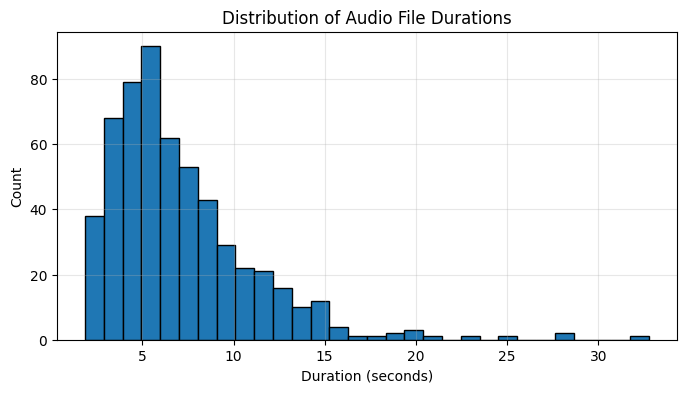

Average duration: 7.07s
Total audio: 1.10 hours


In [9]:
import glob
import pandas as pd

data_root = data_path 

# Clean
atc_root = f"{data_root}/ATCO2-ASRdataset-v1_beta/DATA"
clean_files = sorted(glob.glob(os.path.join(atc_root, "*.wav")))
xml_files = sorted(glob.glob(os.path.join(atc_root, "*.xml")))

print(f"Found {len(clean_files)} audio files and {len(xml_files)} XML files.")
# Create a DataFrame with file info
file_info = []
for wav_path in clean_files:
    # Corresponding XML: same basename but .xml
    base = os.path.splitext(os.path.basename(wav_path))[0]
    xml_path = os.path.join(atc_root, base + ".xml")
    #print(xml_path, wav_path)
    if os.path.exists(xml_path):
        # Get duration using librosa (load metadata only)
        dur = librosa.get_duration(filename=wav_path)
        file_info.append({
            'filename': base,
            'wav_path': wav_path,
            'xml_path': xml_path,
            'duration': dur
        })

df_files = pd.DataFrame(file_info)
print(f"Total usable files: {len(df_files)}")

# Plot duration distribution
plt.figure(figsize=(8,4))
plt.hist(df_files['duration'], bins=30, edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Audio File Durations')
plt.grid(alpha=0.3)
plt.savefig("atc_audio_durations.png", dpi=300)
plt.show()

print(f"Average duration: {df_files['duration'].mean():.2f}s")
print(f"Total audio: {df_files['duration'].sum() / 3600:.2f} hours")

In [10]:
# Noisy
vb_demand_path = f"{data_root}/noisy_trainset_28spk_wav/"        # folder with .wav files
whamvox_path = f"{data_root}/wham_noise/"   # folder with .wav files

# Collect all noise files
noise_files = glob.glob(os.path.join(vb_demand_path, "*.wav")) + \
              glob.glob(os.path.join(whamvox_path, "*.wav"))
print(f"Found {len(noise_files)} noise files.")

target_snrs = [-5, -2, 0, 2, 5, 8] # [-20, -15, -10, -5, 0, 5, 10] # different levels of noise targeted
print(target_snrs)

Found 11678 noise files.
[-5, -2, 0, 2, 5, 8]


In [11]:
# Transcripts extraction
import xml.etree.ElementTree as ET
import re

def clean_atc_text(text):
    """
    Remove ATC annotation tags like [#callsign]...[/#callsign]
    and normalize text for CTC training.
    """
    # remove tags
    text = re.sub(r"\[.*?#.*?\]", "", text)
    
    # remove hesitation or meta tags
    text = re.sub(r"\[.*?\]", "", text)

    # normalize spaces
    text = re.sub(r"\s+", " ", text)

    # lowercase
    text = text.lower().strip()

    return text


# Load the segments from the XML transcript
# Each segment is start, end and text
def load_segments(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    segments = []
    for seg in root.findall('segment'):
        start = float(seg.find('start').text)
        end = float(seg.find('end').text)
        text = seg.find('text').text.strip().lower()
        text = clean_atc_text(text)

        tags = seg.find('tags')
        if tags is not None:
            ct = tags.find('correct_transcript')
            if ct is not None and ct.text == '0':
                continue

        segments.append((start, end, text))

    return segments

In [12]:
class ATCAugmentedDataset(Dataset):
    def __init__(
        self,
        clean_files,
        noise_files,
        snr_levels=[-5, -2, 0, 2, 5, 8],
        num_noise_per_snr=3,
        num_random_mix=2,
        prob_vhf=1.0,
        val=False,
        data_root=atc_root
    ):
        self.noise_files = noise_files
        self.snr_levels = snr_levels
        self.num_noise_per_snr = num_noise_per_snr
        self.num_random_mix = num_random_mix
        self.prob_vhf = prob_vhf

        # ===== SPLIT =====
        N = len(clean_files)
        train_end = int(0.5 * N)
        val_start = int(0.96 * N)

        selected_files = clean_files[val_start:] if val else clean_files[:train_end]

        # ===== LOAD SEGMENTS =====
        self.segments = []

        for f in selected_files:
            base = os.path.splitext(os.path.basename(f))[0]
            xml_path = os.path.join(data_root, base + ".xml")

            if not os.path.exists(xml_path):
                continue

            segments = load_segments(xml_path)

            for (start, end, transcript) in segments:
                self.segments.append((f, start, end, transcript))

        # ===== BUILD VARIANT INDEX =====
        self.variants = []

        for seg_idx in range(len(self.segments)):

            # Fixed SNR + fixed noise
            for snr in self.snr_levels:
                for _ in range(self.num_noise_per_snr):
                    self.variants.append((seg_idx, snr, "fixed"))

            # Random mixes
            for _ in range(self.num_random_mix):
                self.variants.append((seg_idx, None, "random"))

        print(f"Segments: {len(self.segments)}")
        print(f"Total samples (expanded): {len(self.variants)}")

    def __len__(self):
        return len(self.variants)

    def __getitem__(self, idx):
        seg_idx, snr, mode = self.variants[idx]

        clean_file, start, end, transcript = self.segments[seg_idx]

        # ===== LOAD CLEAN SEGMENT =====
        clean, _ = librosa.load(clean_file, sr=SAMPLE_RATE, mono=True)

        start_sample = int(start * SAMPLE_RATE)
        end_sample = int(end * SAMPLE_RATE)

        clean = clean[start_sample:end_sample]

        if random.random() < 0.3:
            noisy = clean.copy()  # identity case
            snr = None
        else: # Augment
            # ===== LOAD NOISE =====
            noise_file = random.choice(self.noise_files)
            noise, _ = librosa.load(noise_file, sr=SAMPLE_RATE, mono=True)
    
            noise = augment_noise(noise, SAMPLE_RATE)
    
            # Match length
            if len(noise) < len(clean):
                repeats = int(np.ceil(len(clean) / len(noise)))
                noise = np.tile(noise, repeats)
            noise = noise[:len(clean)]
    
            # ===== SNR HANDLING =====
            if mode == "random":
                snr = np.random.uniform(-5, 10)
    
            # ===== MIX =====
            noisy = add_noise(clean, noise, snr)
    
            # ===== VHF =====
            if random.random() < self.prob_vhf:
                noisy = vhf_simulation(noisy, SAMPLE_RATE)

        # ===== NORMALIZE =====
        scale = max(np.max(np.abs(clean)), np.max(np.abs(noisy))) + 1e-8
        clean = clean / scale
        noisy = noisy / scale

        return (
            torch.from_numpy(noisy).float(),
            torch.from_numpy(clean).float(),
            snr,
            transcript,
        )

    def collate_fn(self, batch):
        noisy, clean, snrs, transcripts = zip(*batch)

        noisy = torch.nn.utils.rnn.pad_sequence(noisy, batch_first=True)
        clean = torch.nn.utils.rnn.pad_sequence(clean, batch_first=True)

        return noisy, clean, list(snrs), list(transcripts)

In [13]:
class ATCAugmentedDatasetTest(Dataset):
    def __init__(self, clean_files, data_root=atc_root):

        # All files for test
        selected_files = clean_files

        self.data = []
        for f in selected_files:
            base = os.path.splitext(os.path.basename(f))[0]
            xml_path = os.path.join(data_root, base + ".xml")
            if os.path.exists(xml_path): # Proceed if only xml transcripts exist
                self.data.append((f, xml_path))

        print(f"Loaded {len(self.data)} files from {len(selected_files)} selected files")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        clean_file, xml_file = self.data[idx]

        clean, _ = librosa.load(clean_file, sr=SAMPLE_RATE, mono=True)

        segments = load_segments(xml_file)
        
        # if len(segments) == 0:
        #     return self.__getitem__(random.randint(0, len(self.data)-1))  # skip bad sample
        
        #  Pick random segment
        start, end, transcript = random.choice(segments)
        
        start_sample = int(start * SAMPLE_RATE)
        end_sample = int(end * SAMPLE_RATE)
        
        clean = clean[start_sample:end_sample]


        # Normalize
        scale = np.max(np.abs(clean))
        clean = clean / scale

        return (
            torch.from_numpy(clean).float(),
            transcript
        )


    def collate_fn(self, batch):
        clean, transcripts = zip(*batch)
    
        clean = torch.nn.utils.rnn.pad_sequence(clean, batch_first=True)
    
        return clean, list(transcripts)

### 2.1 Data loaders

In [14]:
# To free up ram
import gc
gc.collect()

5571

Datasets locations :
  - `Kaggle`: `"<root>/atco2-asrdataset-v1-beta/ATCO2-ASRdataset-v1_beta/DATA"`, `"<root>/voicebank-demand-16k/noisy_trainset_28spk_wav/"`, `"<root>/wham-noise-reduced-dataset/wham_noise/"`
  - `PSC`: `"<root>/ATCO2-ASRdataset-v1_beta/DATA"`, `"<root>/noisy_trainset_28spk_wav/"`, `"<root>/wham_noise/"`

In [15]:
# Create a dataset object using the AudioDataset class for the training data
train_data = ATCAugmentedDataset(clean_files, noise_files, prob_vhf=1.0)

# Create a dataset object using the AudioDataset class for the validation data
val_data = ATCAugmentedDataset(clean_files, noise_files, prob_vhf=1.0, val=True)

# Create a dataset object using the AudioTestDataset class for the test data
test_data = ATCAugmentedDatasetTest(clean_files)

Segments: 469
Total samples (expanded): 9380
Segments: 26
Total samples (expanded): 520
Loaded 560 files from 560 selected files


In [16]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    # Force deterministic algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
set_seed(seed)

# Create a generator for the DataLoader
g = torch.Generator()
g.manual_seed(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [17]:

# dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=4)

train_loader = torch.utils.data.DataLoader(
    dataset     = train_data,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = True,
    collate_fn = train_data.collate_fn,

    # Seed
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = torch.utils.data.DataLoader(
    dataset     = val_data,
    num_workers = 0,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn = val_data.collate_fn,

    # Seed
    worker_init_fn=seed_worker,
    generator=g
)

test_loader = torch.utils.data.DataLoader(
    dataset     = test_data,
    num_workers = 0,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn = test_data.collate_fn,

    # Seed
    worker_init_fn=seed_worker,
    generator=g
)


print("Batch size: ", config['batch_size'])
print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Val dataset samples = {}, batches = {}".format(val_data.__len__(), len(val_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size:  16
Train dataset samples = 9380, batches = 587
Val dataset samples = 520, batches = 33
Test dataset samples = 560, batches = 35


In [18]:
# sanity check
for data in train_loader:
    x, y, snr, t = data
    print(x.shape, y.shape, len(snr), len(t))
    break

torch.Size([16, 114880]) torch.Size([16, 114880]) 16 16


### Visualization

In [19]:
import soundfile as sf
import os
from IPython.display import Audio, display

def plot_spectrograms(noisy, clean, sample_rate=16000):
    """Plot spectrograms of three signals: noisy, enhanced, clean."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    titles = ['Noisy', 'Clean'] # ['Noisy', 'Enhanced', 'Clean']
    signals = [noisy, clean] #[noisy, enhanced, clean]
    
    for i, (sig, title) in enumerate(zip(signals, titles)):
        # Compute STFT (you can use librosa's stft or your own)
        D = librosa.stft(sig, n_fft=512, hop_length=256, win_length=512, window='hann')
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        img = librosa.display.specshow(S_db, sr=sample_rate, hop_length=256,
                                       x_axis='time', y_axis='hz', ax=axes[i])
        axes[i].set_title(title)
        axes[i].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


# Val loader
output_dir = "audio_samples"
os.makedirs(output_dir, exist_ok=True)

for i, (noisy, clean, snr, t) in enumerate(val_loader):
    snr = snr[0]
    noisy = noisy[0]
    clean = clean[0]
    t = t[0]
    if snr == -2 or snr == -5 or snr == None:
        continue
        
    noisy_np = noisy.squeeze().cpu().numpy()
    clean_np = clean.squeeze().cpu().numpy()
    
    print(f"Sample {i+1}, SNR = {snr if isinstance(snr, torch.Tensor) else snr} \n Text {t}")
    #plot_spectrograms(noisy_np, clean_np)
    
    # Save audio files
    sf.write(os.path.join(output_dir, f"sample_{i+1}_snr{snr}_noisy.wav"), noisy_np, SAMPLE_RATE)
    sf.write(os.path.join(output_dir, f"sample_{i+1}_snr{snr}_clean.wav"), clean_np, SAMPLE_RATE)
    
    # Play in notebook (optional)
    display(Audio(noisy_np, rate=SAMPLE_RATE))
    display(Audio(clean_np, rate=SAMPLE_RATE))
    
    # If you only want to inspect the first sample, break after the first
    break

Sample 2, SNR = 8 
 Text runway one six right cleared to land jetstar five zero eight


## 4. Model Definition

#### LM model

In [20]:
!pwd

/ocean/projects/cis260061p/awolosso


In [21]:
chars = set()
for data in test_loader:
    _, transcripts = data
    transcripts = " ".join(transcripts)
    for token in transcripts:
        chars.add(token)

CTC_LABELS = sorted(chars)   # e.g., ['a','c','d','e',...]
print("CTC labels:", CTC_LABELS)
print(len(CTC_LABELS))

CHAR_ID_MAP = {ch: i+1 for i, ch in enumerate(CTC_LABELS)}  # +1 because index 0 is blank
CHAR_ID_MAP['<blank>'] = 0   # explicitly set blank index
CHAR_ID_MAP['?'] = 41   # explicitly set blank index
print(CHAR_ID_MAP)

CTC labels: [' ', "'", '(', ')', '-', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'á', 'ä', 'é', 'ö', 'ü', 'ý', 'č', 'ň', 'š']
40
{' ': 1, "'": 2, '(': 3, ')': 4, '-': 5, 'a': 6, 'b': 7, 'c': 8, 'd': 9, 'e': 10, 'f': 11, 'g': 12, 'h': 13, 'i': 14, 'j': 15, 'k': 16, 'l': 17, 'm': 18, 'n': 19, 'o': 20, 'p': 21, 'q': 22, 'r': 23, 's': 24, 't': 25, 'u': 26, 'v': 27, 'w': 28, 'x': 29, 'y': 30, 'z': 31, 'á': 32, 'ä': 33, 'é': 34, 'ö': 35, 'ü': 36, 'ý': 37, 'č': 38, 'ň': 39, 'š': 40, '<blank>': 0, '?': 41}


In [22]:
def center_trim(tensor, target_length):
    """
    Trim tensor to match target length (center crop).
    """
    current_length = tensor.size(-1)

    if current_length == target_length:
        return tensor

    if current_length < target_length:
        # pad if too short
        pad = target_length - current_length
        left = pad // 2
        right = pad - left
        return F.pad(tensor, (left, right))

    # crop if too long
    delta = current_length - target_length
    start = delta // 2
    end = start + target_length
    return tensor[..., start:end]

In [51]:
class DemucsBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=8, stride=4):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, stride)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x))


class DemucsEnhancer(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DemucsBlock(1, 32)
        self.enc2 = DemucsBlock(32, 64)
        self.enc3 = DemucsBlock(64, 128)
        self.enc4 = DemucsBlock(128, 256)

        # Decoder
        self.dec4 = nn.ConvTranspose1d(256, 128, 8, 4)
        self.dec3 = nn.ConvTranspose1d(256, 64, 8, 4)
        self.dec2 = nn.ConvTranspose1d(128, 32, 8, 4)
        self.dec1 = nn.ConvTranspose1d(64, 1, 8, 4)

    def forward(self, x):
        x = x.unsqueeze(1)

        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        d4 = self.dec4(e4)
        
        # Align before concat
        e3 = center_trim(e3, d4.size(-1))
        d4 = center_trim(d4, e3.size(-1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        
        e2 = center_trim(e2, d3.size(-1))
        d3 = center_trim(d3, e2.size(-1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))

        e1 = center_trim(e1, d2.size(-1))
        d2 = center_trim(d2, e1.size(-1))
        out = self.dec1(torch.cat([d2, e1], dim=1))

        return out.squeeze(1)

In [24]:
# Assuming `model` is your ATCEnhanceASR instance
wav2vec2_root = os.path.join(os.getcwd(), f'expts/wav2vec2')
os.makedirs(wav2vec2_root, exist_ok=True)
fine_tuned_wav2vec2_path = f'{wav2vec2_root}/wav2vec2_finetuned.pt'
print(fine_tuned_wav2vec2_path)

/ocean/projects/cis260061p/awolosso/expts/wav2vec2/wav2vec2_finetuned.pt


In [46]:
HF_CACHE_DIR = "/ocean/projects/cis260061p/shared/hf_cache"

pretrained_name = "facebook/wav2vec2-base-960h"

wav2vec2 = Wav2Vec2Model.from_pretrained(pretrained_name, cache_dir=HF_CACHE_DIR).to(device)
#wav2vec2.load_state_dict(torch.load(fine_tuned_wav2vec2_path))

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:
class ATCEnhanceASR(nn.Module):
    def __init__(self, enhancement_model, wav2model):
        super().__init__()

        # Enhancement model
        self.enhancer = enhancement_model

        # Wav2Vec2 encoder (NO CTC head)
        self.wav2vec2 = wav2model
        for p in self.wav2vec2.parameters():
            p.requires_grad = False
        for m in self.wav2vec2.modules():
            if isinstance(m, torch.nn.Dropout):
                m.p = 0.0

        for layer in self.wav2vec2.encoder.layers[-3:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Freeze feature extractor (important for stability)
        self.wav2vec2.feature_extractor._freeze_parameters()

        hidden_size = self.wav2vec2.config.hidden_size

        # CTC head
        vocab_size = len(CTC_LABELS) + 1 # included blank
        self.ctc_head = nn.Linear(hidden_size, vocab_size)

    def encode_transcripts(self,transcripts, char_to_idx=CHAR_ID_MAP, pad_token_id=0):
        """
        transcripts: list of strings (e.g., ["hello", "world"])
        Returns:
            labels: (batch, max_len) tensor of indices
            target_lengths: list of lengths
        """
        batch_ids = []
        for transcript in transcripts:
            # transcript is a string like "tower" (no spaces between characters)
            # Convert each character to its index (skip characters not in mapping if any)
            ids = [char_to_idx.get(ch, char_to_idx['?']) for ch in transcript]  # handle unknown chars
            batch_ids.append(ids)
        # Pad
        max_len = max(len(ids) for ids in batch_ids)
        padded = torch.full((len(batch_ids), max_len), pad_token_id, dtype=torch.long)
        for i, ids in enumerate(batch_ids):
            padded[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
        target_lengths = torch.tensor([len(ids) for ids in batch_ids], dtype=torch.long)
        return padded, target_lengths

    def forward(self, noisy_audio, attention_mask=None):
        """
        noisy_audio: (B, T)
        """

        # 1. Enhancement
        enhanced = self.enhancer(noisy_audio)  # (B, T)

        # After enhancer
        # print("enhanced shape:", enhanced.shape)
        # print("has NaN:", torch.isnan(enhanced).any())
        # print("has inf:", torch.isinf(enhanced).any())

        # print("enhanced stats:",
        #       enhanced.min().item(),
        #       enhanced.max().item(),
        #       enhanced.mean().item(),
        #       enhanced.std().item())
        
        

        # enhanced = torch.tanh(enhanced)
        # enhanced = torch.clamp(enhanced, -1.0, 1.0)

        # 2. Wav2Vec2 encoder
        outputs = self.wav2vec2(
            enhanced,
            attention_mask=attention_mask,
            return_dict=True
        )

        hidden_states = outputs.last_hidden_state  # (B, T', H)

        # Before CTC head
        # print("hidden_states shape:", hidden_states.shape)
        # print("has NaN:", torch.isnan(hidden_states).any())

        # 3. CTC logits
        logits = self.ctc_head(hidden_states)  # (B, T', vocab_size)

        return logits, enhanced

In [48]:
from torchinfo import summary
enhancer = ConvUNetEnhancer().to(device)

model = ATCEnhanceASR(
   enhancer,
    wav2vec2
).to(device)
        
summary(model, input_data=x.to(device))

Layer (type:depth-idx)                                  Output Shape              Param #
ATCEnhanceASR                                           [16, 358, 41]             --
├─ConvUNetEnhancer: 1-1                                 [16, 114880]              --
│    └─ConvBlock: 2-1                                   [16, 16, 57440]           --
│    │    └─Conv1d: 3-1                                 [16, 16, 57440]           96
│    │    └─BatchNorm1d: 3-2                            [16, 16, 57440]           32
│    │    └─LeakyReLU: 3-3                              [16, 16, 57440]           --
│    └─ConvBlock: 2-2                                   [16, 32, 28720]           --
│    │    └─Conv1d: 3-4                                 [16, 32, 28720]           2,592
│    │    └─BatchNorm1d: 3-5                            [16, 32, 28720]           64
│    │    └─LeakyReLU: 3-6                              [16, 32, 28720]           --
│    └─ConvBlock: 2-3                                   [

## 5. Training Utilities
Define loss functions (MRSTFT, complex magnitude, perceptual, adversarial), training loop, validation, and checkpointing.

In [49]:
# =========================
# Multi-STFT Loss
# =========================
def stft_loss(pred, target):
    loss = 0
    pred = center_trim(pred, target.size(-1))
    target = center_trim(target, pred.size(-1))
    for n_fft in [256, 512, 1024]:
        pred_stft = torch.stft(pred, n_fft=n_fft, return_complex=True)
        target_stft = torch.stft(target, n_fft=n_fft, return_complex=True)

        loss += F.l1_loss(torch.abs(pred_stft), torch.abs(target_stft))

    return loss / 3

# =========================
# SI-SNR Loss
# =========================
def si_snr_loss(pred, target, eps=1e-8):
    pred = center_trim(pred, target.size(-1))
    target = center_trim(target, pred.size(-1))
    target_energy = torch.sum(target ** 2, dim=-1, keepdim=True)
    proj = torch.sum(pred * target, dim=-1, keepdim=True) * target / (target_energy + eps)

    noise = pred - proj

    ratio = torch.sum(proj ** 2, dim=-1) / (torch.sum(noise ** 2, dim=-1) + eps)
    return -10 * torch.log10(ratio + eps).mean()

In [50]:
from pyctcdecode import build_ctcdecoder
import kenlm

def get_unigrams_from_arpa(arpa_path):
    """Extract unigrams (1-grams) from an ARPA file."""
    unigrams = []
    with open(arpa_path, 'r') as f:
        in_ngram_section = False
        for line in f:
            line = line.strip()
            if line.startswith('\\1-grams:'):
                in_ngram_section = True
                continue
            if in_ngram_section:
                if line.startswith('\\2-grams:'):
                    break
                parts = line.split('\t')
                if len(parts) >= 2:
                    unigrams.append(parts[1])
    return unigrams


def greedy_decode(logits, labels, blank_id=0):
    """
    Args:
        logits: (batch, time, vocab_size) – raw logits from your CTC head
        labels: list of characters, e.g., ['a','b','c',...] (without blank)
        blank_id: index of blank token (default 0)
    Returns:
        List of decoded strings (batch)
    """
    # Get argmax indices along vocab dimension (batch, time)
    argmax_ids = torch.argmax(logits, dim=-1).cpu().numpy()
    
    decoded = []
    for i in range(argmax_ids.shape[0]):
        # Remove consecutive duplicates and blanks
        prev = blank_id
        chars = []
        for idx in argmax_ids[i]:
            if idx != prev and idx != blank_id:
                # idx is 1‑based (blank=0), so subtract 1 to index into labels
                chars.append(labels[idx - 1])
            prev = idx
        decoded.append(''.join(chars))
    return decoded

def beam_search_decode(logits, decoder):
    logits = logits.cpu().numpy()
    #print(logits)
    pred_text = []
    for logit in logits:
        text = decoder.decode(logit, beam_width=10)
        pred_text.append(text)

    return pred_text


def build_decoder(kenlm_path, unigrams):
    decoder = build_ctcdecoder(
        labels=CTC_LABELS,
        kenlm_model_path=kenlm_path,
        unigrams=unigrams,
        alpha=config["lm_alpha"],
        beta=config["lm_beta"],
    )
    return decoder


ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)
unigrams_list = get_unigrams_from_arpa('kenlm/build/lm_chars.arpa')
decoder = build_decoder("kenlm/build/lm_chars.bin", unigrams_list)

# Integrate decoder into processor
# from transformers import Wav2Vec2ProcessorWithLM
# processor_with_lm = Wav2Vec2ProcessorWithLM(
#     feature_extractor=processor.feature_extractor,
#     tokenizer=processor.tokenizer,
#     decoder=decoder
# )

Only 42 unigrams passed as vocabulary. Is this small or artificial data?


In [51]:
import torchmetrics.text as tmt

def train_one_epoch(model, loader, optimizer, scaler, scheduler=None):
    model.eval()
    total_loss = 0

    progress_bar = tqdm(total=len(loader), dynamic_ncols=True, leave=False, position=0, desc='Train')
    for i, batch in enumerate(loader):
        noisy, clean, snrs, transcripts = batch
    
        noisy = noisy.to(device)
        clean = clean.to(device)
    
        # Encode transcripts to labels
        labels, target_lengths = model.encode_transcripts(transcripts)
        labels = labels.to(device)

        
        # print("Transcript:", transcripts[0])
        # print("Encoded labels:", labels[0][:len(transcripts[0])].tolist())
        
        # Forward
        logits, enhanced = model(noisy)
    
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    
        input_lengths = torch.full(
            size=(logits.size(0),),
            fill_value=logits.size(1),
            dtype=torch.long
        ).to(device)

    
        # ===== LOSSES =====
        loss_ctc = ctc_loss_fn(
            log_probs.transpose(0, 1),
            labels,
            input_lengths,
            target_lengths
        )
    
        loss_sisnr = si_snr_loss(enhanced, clean)
        loss_stft = stft_loss(enhanced, clean)
    
        loss = (
            config["lambda_ctc"] * loss_ctc +
            config["lambda_sisnr"] * loss_sisnr +
            config["lambda_stft"] * loss_stft
        )

        #print(loss)
            
        # scaler.scale(loss).backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clipping"])
        # scaler.step(optimizer)
        # scaler.update()
        # optimizer.zero_grad()
        if torch.isnan(loss).any() or torch.isinf(loss).any():
            print(f"NaN/Inf detected at step {i}, skipping update")
            optimizer.zero_grad()
            continue
            
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            config["gradient_clipping"]
        )
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        for name, param in model.named_parameters():
            if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                print(f"NaN grad in {name}")
                optimizer.zero_grad()
                break
    
        total_loss += loss.item()

        current_lr = optimizer.param_groups[0]['lr']
        progress_bar.set_postfix(
            Loss="{:.04f}".format(float(total_loss / (i + 1)))
        )
        progress_bar.update() # Update tqdm bar
        
        # Clean up
        del noisy, clean, snrs, transcripts
        del logits, enhanced, log_probs, input_lengths, target_lengths
        del loss_ctc, loss_sisnr, loss_stft
        torch.cuda.empty_cache()
        
        
    progress_bar.close() # You need this to close the tqdm bar

    return total_loss / len(loader)

def validate_epoch(model, loader, decoder=None):
    model.eval()

    total_loss = 0
    progress_bar = tqdm(total=len(loader), dynamic_ncols=True, leave=False, position=0, desc='Val')
    results = []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            noisy, clean, snrs, transcripts = batch
    
            noisy = noisy.to(device)
            clean = clean.to(device)

            # Encode transcripts to labels
            labels, target_lengths = model.encode_transcripts(transcripts)
            labels = labels.to(device)
        
            # Forward
            logits, enhanced = model(noisy)
            #print(logits.shape)
        
            log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        
            input_lengths = torch.full(
                size=(logits.size(0),),
                fill_value=logits.size(1),
                dtype=torch.long
            ).to(device)
        
            # ===== LOSSES =====
            loss_ctc = ctc_loss_fn(
                log_probs.transpose(0, 1),
                labels,
                input_lengths,
                target_lengths
            )
        
            loss_sisnr = si_snr_loss(enhanced, clean)
            loss_stft = stft_loss(enhanced, clean)
        
            loss = (
                config["lambda_ctc"] * loss_ctc +
                config["lambda_sisnr"] * loss_sisnr +
                config["lambda_stft"] * loss_stft
            )

            total_loss += loss.item()

            if decoder is None:
                pred_text = greedy_decode(logits, CTC_LABELS, blank_id=0)
            else:
                pred_text = beam_search_decode(logits, decoder)

            results.extend([{
                "target": t,
                "generated": p
            } for t,p in zip(transcripts, pred_text)])

            progress_bar.set_postfix(
                Loss="{:.04f}".format(float(total_loss / (i + 1))),
            )
            progress_bar.update() # Update tqdm bar

    targets = [r['target'] for r in results]
    predicted = [r['generated'] for r in results]
    
    wer_metric = tmt.WordErrorRate()
    wer = wer_metric(predicted, targets).item() * 100
    progress_bar.close() # You need this to close the tqdm bar
    return total_loss / len(loader), wer, results


def compute_wer(model, loader, decoder):
    model.eval()

    wers = []
    results = []
    wer_metric = tmt.WordErrorRate()

    with torch.no_grad():
        for noisy, clean, snrs, transcripts in loader:

            noisy = noisy.to(device)

            logits, _ = model(noisy)

            if decoder is None:
                pred_text = greedy_decode(logits, processor)
            else:
                pred_text = beam_search_decode(logits, decoder)


            results.append({
                "target": transcripts,
                "generated": pred_text
            })
            for p, t in zip(pred_text, transcripts):
                wers.append(wer_metric(t, p).item() * 100)

    return sum(wers) / len(wers), results

### Wandb

In [52]:
import datetime
import wandb

# Use wandb? Resume Training?
USE_WANDB = config['wandb']

RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# Create your wandb run

run_name = f"{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')}_{config['Name']}"

# If you are resuming an old run
if USE_WANDB:

    wandb.login(key="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") #TODO
    
    if RESUME_LOGGING:
        run = wandb.init(
            id     = "", ### Insert specific run id here if you want to resume a previous run
            resume = "must", ### You need this to resume previous runs
            project = "ATC-EnhanceNet-ablations", ### Project should be created in your wandb
            settings = wandb.Settings(_service_wait=300)
        )


    else:
        run = wandb.init(
            name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True, ### Allows reinitalizing runs when you re-run this cell
            project = "ATC-EnhanceNet-ablations-2-Decmus", ### Project should be created in your wandb account
            config  = config ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = f"{str(model)}"
        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### log it in your wandb run with wandb.save()
        wandb.save('model_arch.txt')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


epoch,▁█▁█
lr,██▁▁
train_loss,▆▁█▃
val_loss,█▁██
val_wer,▁▁▁▁
epoch,1
lr,1e-05
train_loss,9.97698
val_loss,8.9853
val_wer,100


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


## Training loop

In [53]:
# To free up ram
import gc
gc.collect()

1836

In [54]:
import json

start_epoch = 0
best_wer = float("inf")
num_epochs = config["epochs"]

# scaler
scaler = torch.cuda.amp.GradScaler()

# Optimizers and Schedulers
config["lr"] = 0.0001
# optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
optimizer = torch.optim.AdamW([
    {'params': model.enhancer.parameters(), 'lr': 1e-4},
    {'params': model.ctc_head.parameters(), 'lr': 1e-4},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
# optimizer = torch.optim.AdamW(model.ctc_head.parameters(), lr=0.0008)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=3)


checkpoint_root = os.path.join(os.getcwd(), f'expts/{run_name}/checkpoints')
os.makedirs(checkpoint_root, exist_ok=True)
best_wer_checkpoint_path = f'{checkpoint_root}/best_model_wer.pt'
last_checkpoint_path = f'{checkpoint_root}/last_epoch.pt'


text_root = os.path.join(os.getcwd(), f'expts/{run_name}/texts')
os.makedirs(text_root, exist_ok=True)

def save_generated_text(text: dict, suffix: str):
    """Save generated text to JSON file."""
    text_path = os.path.join(text_root, f"text_{suffix}.json")
    with open(text_path, "w") as f:
        json.dump(text, f, indent=4)

In [55]:
# RESUME_TRAINING = True

# if RESUME_TRAINING:
#     #load_last_checkpoint_path = "expts/2026-04-09_14-01_Anderson Awolossou/checkpoints/last_epoch.pt"
#     load_last_checkpoint_path = last_checkpoint_path
#     checkpoint = torch.load(load_last_checkpoint_path, weights_only=False)
    
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
#     start_epoch = checkpoint['epoch'] + 1
#     best_wer = checkpoint.get('best_wer', float("inf"))
    
# !pwd

In [56]:
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [57]:
for epoch in range(start_epoch, num_epochs+1):

    print(f"\nEpoch {epoch+1}/{config['epochs']}")

    # =========================
    # Train
    # =========================
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)

    # =========================
    # Validate
    # =========================
    val_loss, val_wer, val_results = validate_epoch(model, val_loader)

    # =========================
    # LR
    # =========================
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | WER: {val_wer:.4f} | LR: {current_lr:.6f}")

    # =========================
    # Scheduler
    # =========================
    #scheduler.step(val_wer)  # WER 
    #scheduler.step()

    # =========================
    # W&B logging
    # =========================
    if config["wandb"]:
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_wer": val_wer,
            "lr": current_lr
        })

    # =========================
    # Save last model
    # =========================
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_wer": best_wer
    }, last_checkpoint_path)
    
    wandb.save("last_epoch.pt")

    # save predicted text
    #print(val_results)
    save_generated_text(val_results, f'val_epoch_{epoch}')

    # =========================
    # Save best WER
    # =========================
    if val_wer < best_wer:
        best_wer = val_wer

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_wer": best_wer
        }, best_wer_checkpoint_path)

        print(f"New best WER: {best_wer:.4f}")

        if config["wandb"]:
            wandb.save("best_model_wer.pt")


Epoch 1/100


Train Loss: 14.7306
Val Loss: 8.9685 | WER: 100.0000 | LR: 0.000100
New best WER: 100.0000

Epoch 2/100


Train Loss: 9.5766
Val Loss: 4.2676 | WER: 100.0000 | LR: 0.000100

Epoch 3/100


Train Loss: 3.5179
Val Loss: 3.1102 | WER: 100.0000 | LR: 0.000100

Epoch 4/100


Train Loss: 2.9474
Val Loss: 2.9297 | WER: 99.9840 | LR: 0.000100
New best WER: 99.9840

Epoch 5/100


...

Train Loss: 2.2191
Val Loss: 2.3805 | WER: 99.7923 | LR: 0.000100
New best WER: 99.7923

Epoch 10/100


Train Loss: 2.1285
Val Loss: 2.4135 | WER: 99.8243 | LR: 0.000100

Epoch 11/100


Train Loss: 2.0971
Val Loss: 2.4122 | WER: 99.9042 | LR: 0.000100

Epoch 12/100


Train:   5%|██████▍                                                                                                                       | 30/587 [00:28<08:14,  1.13it/s, Loss=2.1087]

KeyboardInterrupt: 

## Prediction

Generate enhanced audio file from noisy audio file

In [78]:
# Load best checkpoint

# last_checkpoint_path = f'{checkpoint_root}/last_checkpoint.pt'
# best_pesq_checkpoint_path = f'{checkpoint_root}/best_model_pesq.pt'
# best_stoi_checkpoint_path = f'{checkpoint_root}/best_model_stoi.pt'
# best_si_snr_checkpoint_path = f'{checkpoint_root}/best_model_si_snr.pt'

print(best_wer_checkpoint_path)

checkpoint = torch.load(best_wer_checkpoint_path, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

/ocean/projects/cis260061p/awolosso/expts/2026-04-11_09-04_Anderson Awolossou/checkpoints/best_model_wer.pt


<All keys matched successfully>

In [83]:
# Save best wav2vec2
best_wav2vec2_path = f'{wav2vec2_root}/wav2vec2_best_wer.pt'
print(best_wav2vec2_path)
torch.save(model.wav2vec2.state_dict(), best_wav2vec2_path)

/ocean/projects/cis260061p/awolosso/expts/wav2vec2/wav2vec2_best_wer.pt


In [65]:
def predict(generator, test_audio_path, output_path, device):
    """Enhance a single audio file and save the result."""
    model.eval()
    audio, sr = librosa.load(test_audio_path, sr=SAMPLE_RATE, mono=True)
    audio_t = torch.from_numpy(audio).float().unsqueeze(0).to(device)  # (1, T)
    with torch.no_grad():
        _, enhanced_wave = model(audio_t)
        enhanced = enhanced_wave.squeeze().cpu().numpy()
    sf.write(output_path, enhanced, SAMPLE_RATE)
    print(f"Enhanced audio saved to {output_path}")

In [66]:
prediction_root = os.path.join(os.getcwd(), 'predictions')
os.makedirs(prediction_root, exist_ok=True)

audio_files = clean_files[:10] # First 10
for test_audio_path in audio_files:
    file_name = os.path.splitext(os.path.basename(test_audio_path))[0]
    output_path = os.path.join(prediction_root, file_name + ".wav")
    print(f"{test_audio_path} -> {output_path}")
    predict(model, test_audio_path, output_path, device)


/local/dataset/ATCO2-ASRdataset-v1_beta/DATA/LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav -> /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav
Enhanced audio saved to /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav
/local/dataset/ATCO2-ASRdataset-v1_beta/DATA/LKPR_RUZYNE_Radar_120_520MHz_20201025_120512.wav -> /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_120512.wav
Enhanced audio saved to /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_120512.wav
/local/dataset/ATCO2-ASRdataset-v1_beta/DATA/LKPR_RUZYNE_Radar_120_520MHz_20201025_121325.wav -> /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_121325.wav
Enhanced audio saved to /ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_121325.wav
/local/dataset/ATCO2-ASRdataset-v1_beta/DATA/LKPR_RUZYN

In [67]:
# Play in notebook (optional)
display(Audio("/local/dataset/ATCO2-ASRdataset-v1_beta/DATA/LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav"))
display(Audio("/ocean/projects/cis260061p/awolosso/predictions/LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav"))

## Evaluation

In [75]:
from tqdm.auto import tqdm

dataloader = test_loader
model.eval()

results = []

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Test predictions"):
        #noisy, clean, _, transcripts = batch
        clean, transcripts = batch

        clean = clean.to(device)

        # Encode transcripts to labels
        labels, target_lengths = model.encode_transcripts(transcripts)
        labels = labels.to(device)
    
        # Forward
        logits, enhanced = model(clean)
        #print(logits.shape)
        
        pred_text = greedy_decode(logits, CTC_LABELS, blank_id=0)

        results.extend([{
            "target": t,
            "generated": p
        } for t,p in zip(transcripts, pred_text)])


targets = [r['target'] for r in results]
predicted = [r['generated'] for r in results]

wer_metric = tmt.WordErrorRate()
wer = wer_metric(predicted, targets).item() * 100

print(f" Wer on test data: {wer} ")

Test predictions:   0%|          | 0/35 [00:00<?, ?it/s]

 Wer on test data: 94.92288827896118 


In [76]:
print(results[:10])

[{'target': 'oscar kilo papa mike bravo descend flight level one hundred', 'generated': 'anfeopoponmi beravo on teneundr'}, {'target': 'oscar kilo kilo echo alfa praha radar identified climb flight level one hundred ifr flight starts now time zero five cleared to destination via flight plan route', 'generated': 'o particular cilar cofaardaridentifieconfonta vo one ambre da fa fiea now tive eo five foto efinisio n i fi fa ro'}, {'target': 'ryanair seven three alpha hotel', 'generated': 'o a o to'}, {'target': 'oscar kilo kilo uniform november proceed direct baltu', 'generated': 'ca co ca oo o profidatacboto'}, {'target': 'eurowings seven alfa bravo turn right heading two one zero cleared ils approach runway two four report established', 'generated': 'yohaving comen o fobenama to etingtwo oneo cer di tetro tom te tofor epotetoblatio'}, {'target': 'i do confirm', 'generated': 'aeo'}, {'target': 'climb to flight level one six zero', 'generated': 'fimbto fivd to foontetix yo no'}, {'target'